In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
import warnings
warnings.filterwarnings('ignore')

# Configuração de estilo
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ Bibliotecas importadas com sucesso!")


✅ Bibliotecas importadas com sucesso!


In [22]:
caminho_arquivo = 'desafio_indicium_imdb.csv'

try:
    df = pd.read_csv(caminho_arquivo)
    print(f"✅ Dataset carregado com sucesso!")
    print(f"📊 Shape do dataset: {df.shape}")
    print(f"📋 Colunas: {df.columns.tolist()}")
    
except FileNotFoundError:
    print(f"❌ Arquivo {caminho_arquivo} não encontrado!")
    print("⚠️ Verifique o caminho do arquivo")

✅ Dataset carregado com sucesso!
📊 Shape do dataset: (999, 16)
📋 Colunas: ['Unnamed: 0', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']


In [23]:
print("PRÉ-PROCESSAMENTO")
print("=" * 40)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("✅ Coluna 'Unnamed: 0' removida")

print("\n📊 DADOS FALTANTES:")
print(df.isnull().sum())

PRÉ-PROCESSAMENTO
✅ Coluna 'Unnamed: 0' removida

📊 DADOS FALTANTES:
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64


In [24]:
def limpar_valor_monetario(valor):
    """Limpar valores monetários da coluna Gross"""
    if pd.isna(valor):
        return 0
    if isinstance(valor, str):
        valor_limpo = ''.join(c for c in valor if c.isdigit() or c == '.')
        return float(valor_limpo) if valor_limpo else 0
    return float(valor)

def limpar_runtime(valor):
    """Extrair minutos da coluna Runtime"""
    if pd.isna(valor):
        return np.nan
    if isinstance(valor, str):
        numeros = re.findall(r'\d+', valor)
        return int(numeros[0]) if numeros else np.nan
    return valor

df['Gross'] = df['Gross'].apply(limpar_valor_monetario)
df['Runtime'] = df['Runtime'].apply(limpar_runtime)

print("✅ Colunas Gross e Runtime limpas")

✅ Colunas Gross e Runtime limpas


In [25]:
df['Meta_score'] = df['Meta_score'].fillna(df['Meta_score'].median())
df['Runtime'] = df['Runtime'].fillna(df['Runtime'].median())
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')
df['Released_Year'] = df['Released_Year'].fillna(df['Released_Year'].median())

numeric_columns = ['No_of_Votes', 'IMDB_Rating']
for col in numeric_columns:
    if col in df.columns and df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

print("✅ Valores faltantes tratados")

✅ Valores faltantes tratados


##Padronização de classificação indicativa para melhor análise (foi utilizado o guia Prime Video para fazer as converções)

In [26]:
def padronizar_certificados(certificado):
    """Padronizar classificações para sistema americano"""
    if pd.isna(certificado):
        return 'Unknown'
    
    certificado = str(certificado).strip().upper()
    
    if certificado in ['UA', 'U/A', 'TV-14']:
        return 'PG-13'
    elif certificado in ['TV-PG']:
        return 'PG'
    elif certificado in ['U']:
        return 'G'
    elif certificado in ['A', 'TV-MA']:
        return 'R'
    else:
        return certificado

In [27]:
print("🎯 PADRONIZAÇÃO DE CLASSIFICAÇÕES")
print("=" * 40)

print("📊 Distribuição antes:")
print(df['Certificate'].value_counts().head())

df['Certificate'] = df['Certificate'].apply(padronizar_certificados)
df['Certificate'] = df['Certificate'].fillna('Unknown')

print("\n📊 Distribuição após:")
print(df['Certificate'].value_counts())


🎯 PADRONIZAÇÃO DE CLASSIFICAÇÕES
📊 Distribuição antes:
Certificate
U        234
A        196
UA       175
R        146
PG-13     43
Name: count, dtype: int64

📊 Distribuição após:
Certificate
R           343
G           246
PG-13       220
Unknown     101
PG           40
PASSED       34
APPROVED     11
GP            2
UNRATED       1
16            1
Name: count, dtype: int64


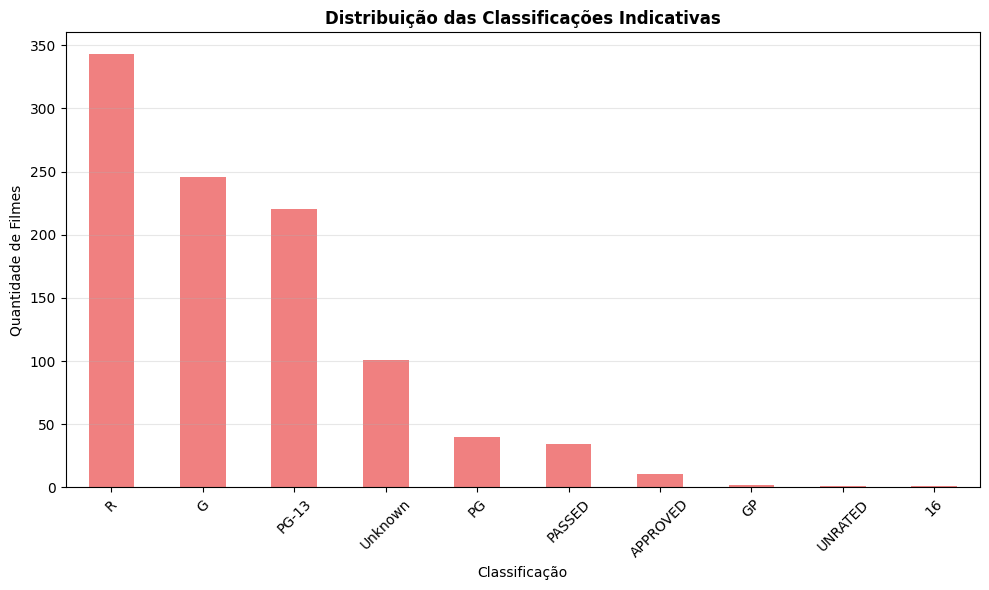

In [28]:
plt.figure(figsize=(10, 6))
df['Certificate'].value_counts().plot(kind='bar', color='lightcoral')
plt.title('Distribuição das Classificações Indicativas', fontweight='bold')
plt.ylabel('Quantidade de Filmes')
plt.xlabel('Classificação')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
print("📈 ESTATÍSTICAS GERAIS")
print("=" * 30)

print(f"🎬 Total de filmes: {len(df):,}")
print(f"📅 Período: {int(df['Released_Year'].min())} - {int(df['Released_Year'].max())}")
print(f"💰 Bilheteria total: ${df['Gross'].sum():,.0f}")
print(f"📊 Bilheteria média: ${df['Gross'].mean():,.0f}")
print(f"⏰ Duração média: {df['Runtime'].mean():.1f} minutos")


📈 ESTATÍSTICAS GERAIS
🎬 Total de filmes: 999
📅 Período: 1920 - 2020
💰 Bilheteria total: $56,508,536,507
📊 Bilheteria média: $56,565,102
⏰ Duração média: 122.9 minutos


In [30]:
print("📊 ESTATÍSTICAS DESCRITIVAS:")
df[['Gross', 'Meta_score', 'Runtime', 'IMDB_Rating', 'No_of_Votes']].describe()


📊 ESTATÍSTICAS DESCRITIVAS:


,Gross,Meta_score,Runtime,IMDB_Rating,No_of_Votes
count,9.990000e+02,999.000000,999.000000,999.000000,9.990000e+02
mean,5.656510e+07,78.131131,122.871872,7.947948,2.716214e+05
std,1.032860e+08,11.373766,28.101227,0.272290,3.209126e+05
min,0.000000e+00,28.000000,45.000000,7.600000,2.508800e+04
25%,4.422285e+05,72.000000,103.000000,7.700000,5.547150e+04
50%,1.068028e+07,79.000000,119.000000,7.900000,1.383560e+05
75%,6.157656e+07,85.500000,137.000000,8.100000,3.731675e+05
max,9.366622e+08,100.000000,321.000000,9.200000,2.303232e+06


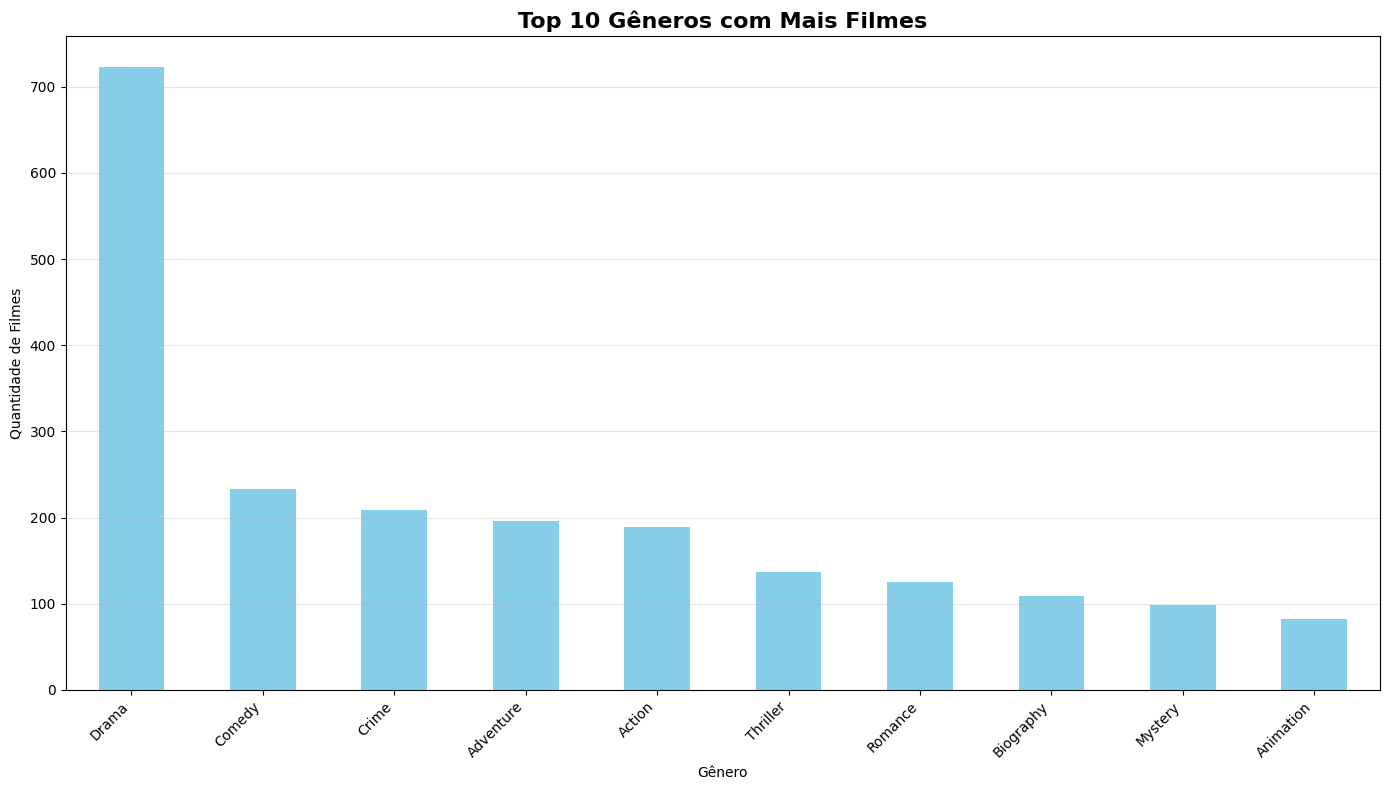

In [31]:
genres_list = df['Genre'].str.split(', ').explode()
genre_stats = genres_list.value_counts()

plt.figure(figsize=(14, 8))
genre_stats.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Gêneros com Mais Filmes', fontsize=16, fontweight='bold')
plt.ylabel('Quantidade de Filmes')
plt.xlabel('Gênero')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
genre_profit = df.assign(Genre=df['Genre'].str.split(', ')).explode('Genre')
genre_profit_analysis = genre_profit.groupby('Genre').agg({
    'Gross': ['mean', 'sum', 'count'],
    'Meta_score': 'mean'
}).round(2)

print("💰 TOP 10 GÊNEROS POR RENTABILIDADE:")
genre_profit_analysis.sort_values(('Gross', 'mean'), ascending=False).head(10)


💰 TOP 10 GÊNEROS POR RENTABILIDADE:


Gross                     Meta_score
                   mean           sum count       mean
Genre                                                 
Adventure  1.437465e+08  2.817432e+10   196      78.09
Sci-Fi     1.347703e+08  9.029610e+09    67      76.78
Action     1.165785e+08  2.203333e+10   189      74.68
Animation  1.045588e+08  8.573824e+09    82      80.91
Fantasy    9.215974e+07  6.082543e+09    66      76.67
Family     7.965656e+07  4.460768e+09    56      78.00
Sport      5.367202e+07  1.019768e+09    19      73.21
Comedy     5.256623e+07  1.224793e+10   233      78.16
Biography  4.866585e+07  5.304578e+09   109      76.61
Thriller   4.711262e+07  6.454429e+09   137      77.20

In [33]:
yearly_stats = df.groupby('Released_Year').agg({
    'Gross': ['mean', 'sum', 'count'],
    'Meta_score': 'mean',
    'Runtime': 'mean'
})

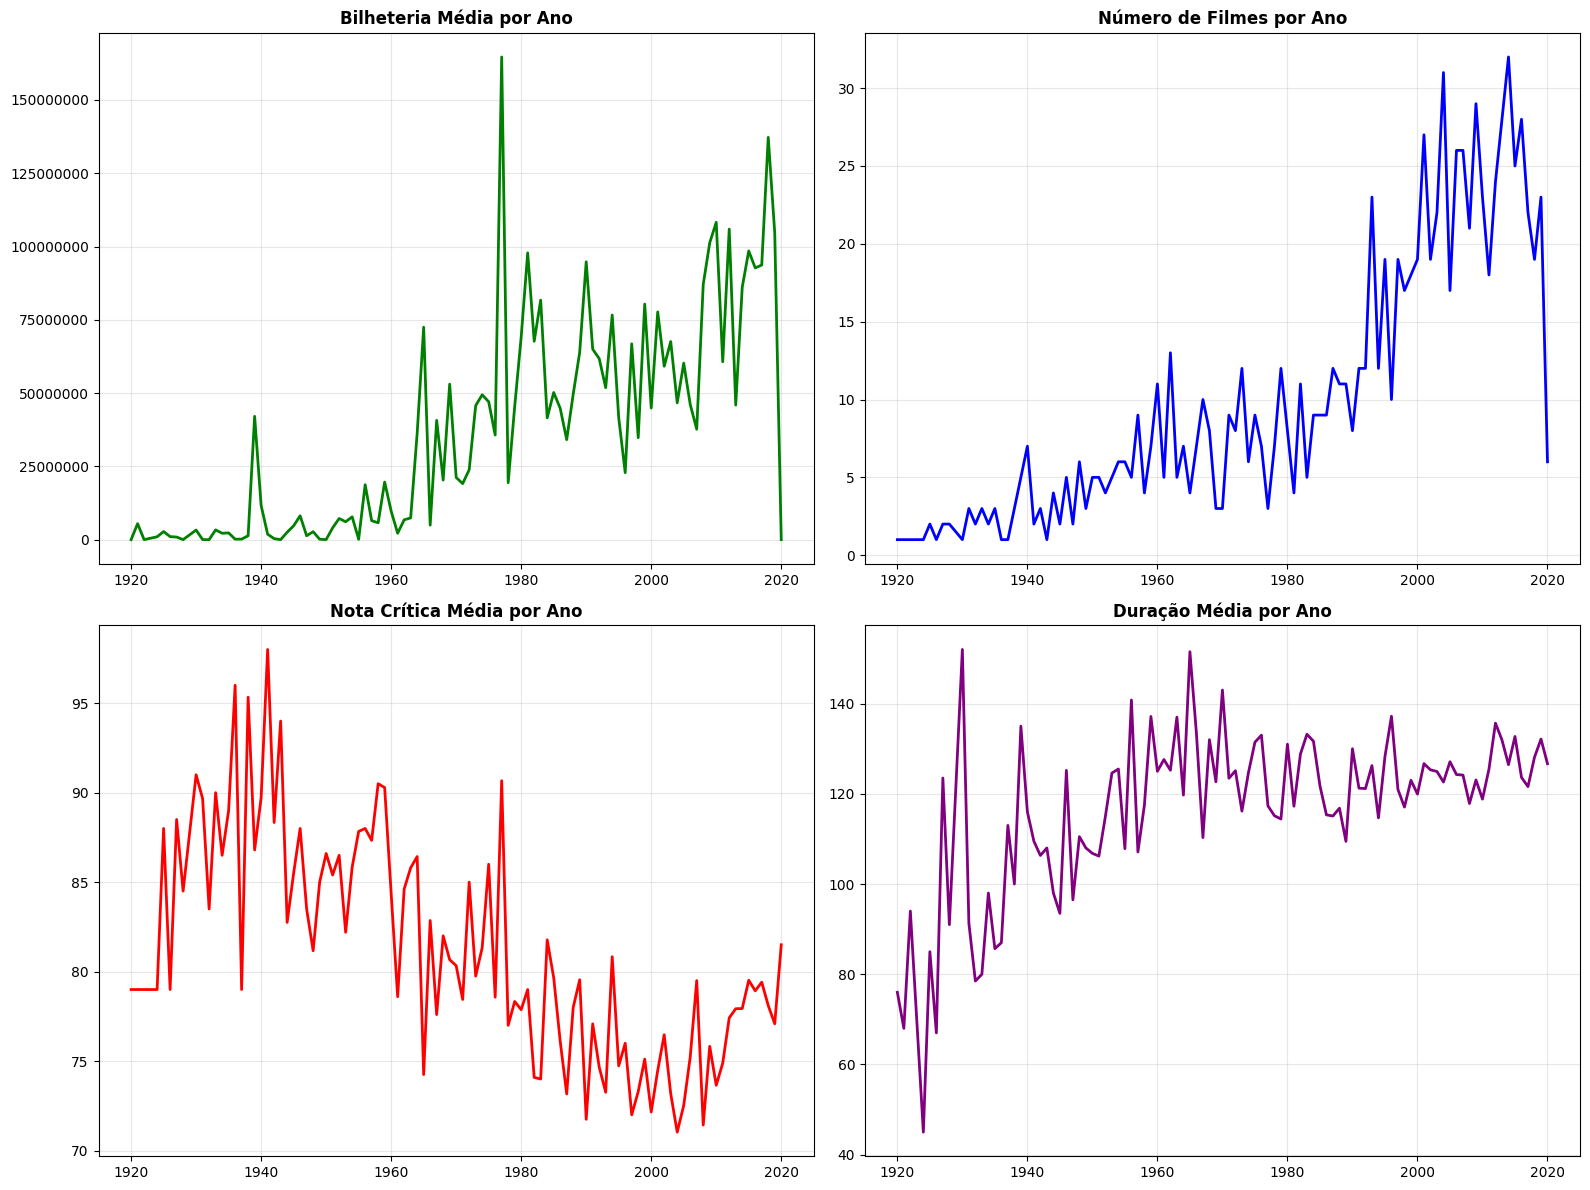

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Bilheteria Média
axes[0, 0].plot(yearly_stats.index, yearly_stats[('Gross', 'mean')], color='green', linewidth=2)
axes[0, 0].set_title('Bilheteria Média por Ano', fontweight='bold')
axes[0, 0].ticklabel_format(style='plain', axis='y')
axes[0, 0].grid(alpha=0.3)

# Gráfico 2: Quantidade de Filmes
axes[0, 1].plot(yearly_stats.index, yearly_stats[('Gross', 'count')], color='blue', linewidth=2)
axes[0, 1].set_title('Número de Filmes por Ano', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Gráfico 3: Nota Média
axes[1, 0].plot(yearly_stats.index, yearly_stats[('Meta_score', 'mean')], color='red', linewidth=2)
axes[1, 0].set_title('Nota Crítica Média por Ano', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Gráfico 4: Duração Média
axes[1, 1].plot(yearly_stats.index, yearly_stats[('Runtime', 'mean')], color='purple', linewidth=2)
axes[1, 1].set_title('Duração Média por Ano', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [35]:
director_analysis = df.groupby('Director').agg({
    'Gross': ['mean', 'sum', 'count'],
    'Meta_score': 'mean'
}).sort_values(('Gross', 'mean'), ascending=False)

print("🎥 TOP 10 DIRETORES:")
director_analysis.head(10)

# %%
# Célula 17: Top atores
def analyze_star_performance(star_column):
    return df.groupby(star_column).agg({
        'Gross': ['mean', 'sum'],
        'Meta_score': 'mean'
    }).sort_values(('Gross', 'mean'), ascending=False)

star1_perf = analyze_star_performance('Star1')
print("🌟 TOP 10 ATORES:")
star1_perf.head(10)

🎥 TOP 10 DIRETORES:
🌟 TOP 10 ATORES:


Gross               Meta_score
                           mean           sum       mean
Star1                                                   
Daisy Ridley       9.366622e+08  9.366622e+08  80.000000
Sam Worthington    7.605076e+08  7.605076e+08  83.000000
Joe Russo          5.512599e+08  2.205039e+09  72.750000
Felicity Jones     5.321773e+08  5.321773e+08  65.000000
Henry Thomas       4.351106e+08  4.351106e+08  91.000000
Craig T. Nelson    4.350114e+08  8.700228e+08  85.000000
Rob Minkoff        4.227838e+08  4.227838e+08  88.000000
Robert Downey Jr.  3.835734e+08  1.150720e+09  68.333333
Lee Unkrich        3.808433e+08  3.808433e+08  90.000000
Chris Pratt        3.614949e+08  7.229897e+08  71.500000

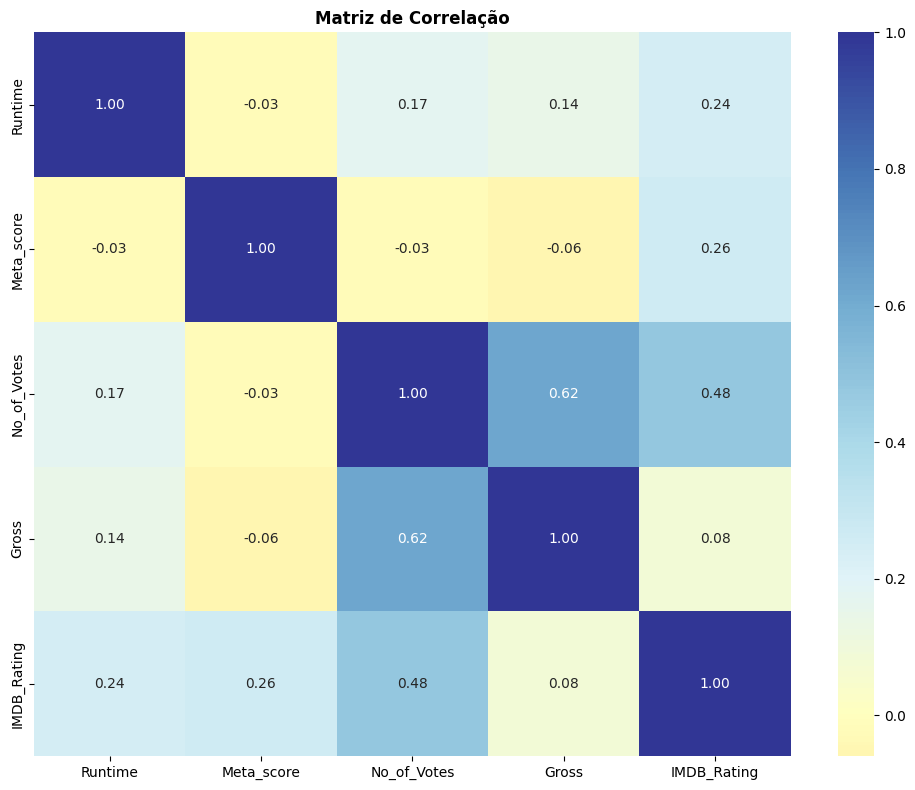

In [36]:
correlation_cols = ['Runtime', 'Meta_score', 'No_of_Votes', 'Gross', 'IMDB_Rating']
correlation_matrix = df[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu', center=0, fmt='.2f')
plt.title('Matriz de Correlação', fontweight='bold')
plt.tight_layout()
plt.show()


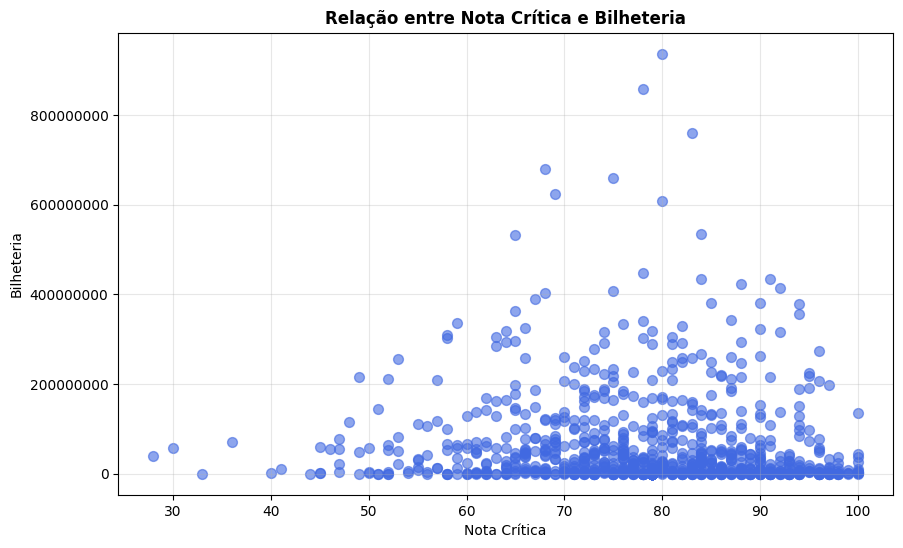

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Meta_score'], df['Gross'], alpha=0.6, s=50, color='royalblue')
plt.xlabel('Nota Crítica')
plt.ylabel('Bilheteria')
plt.title('Relação entre Nota Crítica e Bilheteria', fontweight='bold')
plt.gca().ticklabel_format(style='plain', axis='y')
plt.grid(alpha=0.3)
plt.show()

In [38]:
max_gross = df['Gross'].max()
df['Success_Score'] = (df['Gross'] / max_gross * 0.7 + df['Meta_score'] / 100 * 0.3)

top_successful = df.nlargest(10, 'Success_Score')[[
    'Series_Title', 'Genre', 'Director', 'Gross', 'Meta_score', 'Success_Score'
]]

print("🏆 TOP 10 FILMES MAIS SUCEDIDOS:")
top_successful

🏆 TOP 10 FILMES MAIS SUCEDIDOS:


,Series_Title,Genre,Director,Gross,Meta_score,Success_Score
476,Star Wars: Episode VII - The Force Awakens,"Action, Adventure, Sci-Fi",J.J. Abrams,936662225.0,80.0,0.940000
58,Avengers: Endgame,"Action, Adventure, Drama",Anthony Russo,858373000.0,78.0,0.875492
622,Avatar,"Action, Adventure, Fantasy",James Cameron,760507625.0,83.0,0.817354
651,Titanic,"Drama, Romance",James Cameron,659325379.0,75.0,0.717737
59,Avengers: Infinity War,"Action, Adventure, Sci-Fi",Anthony Russo,678815482.0,68.0,0.711302
890,Incredibles 2,"Animation, Action, Adventure",Brad Bird,608581744.0,80.0,0.694814
356,The Avengers,"Action, Adventure, Sci-Fi",Joss Whedon,623279547.0,69.0,0.672798
1,The Dark Knight,"Action, Crime, Drama",Christopher Nolan,534858444.0,84.0,0.651718
687,E.T. the Extra-Terrestrial,"Family, Sci-Fi",Steven Spielberg,435110554.0,91.0,0.598173
581,Rogue One,"Action, Adventure, Sci-Fi",Gareth Edwards,532177324.0,65.0,0.592714


In [39]:
successful_patterns = df[df['Success_Score'] > 0.7].copy()

print("💡 RECOMENDAÇÕES PARA PRÓXIMO FILME")
print("=" * 40)

max_year = df['Released_Year'].max()
recent_years = df['Released_Year'] >= (max_year - 5)
recent_genres = df[recent_years]['Genre'].str.split(', ').explode().value_counts()

print(f"🎯 Gêneros promissores: {recent_genres.index[:3].tolist()}")
print(f"🎯 Diretores recomendados: {director_analysis.index[:3].tolist()}")
print(f"🎯 Atores recomendados: {star1_perf.index[:3].tolist()}")


💡 RECOMENDAÇÕES PARA PRÓXIMO FILME
🎯 Gêneros promissores: ['Drama', 'Comedy', 'Action']
🎯 Diretores recomendados: ['Anthony Russo', 'Gareth Edwards', 'J.J. Abrams']
🎯 Atores recomendados: ['Daisy Ridley', 'Sam Worthington', 'Joe Russo']


In [40]:
runtime_analysis = successful_patterns.groupby('Runtime').size()
certificate_analysis = successful_patterns['Certificate'].value_counts()

print("⚙️ CARACTERÍSTICAS TÉCNICAS IDEIAS:")
if not runtime_analysis.empty:
    print(f"   • Duração ideal: {runtime_analysis.idxmax()} minutos")
if not certificate_analysis.empty:
    print(f"   • Classificação ideal: {certificate_analysis.index[0]}")

print(f"   • Lançamento ideal: {datetime.now().year + 1}")

⚙️ CARACTERÍSTICAS TÉCNICAS IDEIAS:
   • Duração ideal: 138 minutos
   • Classificação ideal: PG-13
   • Lançamento ideal: 2026


In [41]:
resultados = {
    'melhores_generos': genre_profit_analysis.sort_values(('Gross', 'mean'), ascending=False).index[:3].tolist(),
    'melhores_diretores': director_analysis.index[:3].tolist(),
    'melhores_atores': star1_perf.index[:3].tolist(),
    'duracao_ideal': runtime_analysis.idxmax() if not runtime_analysis.empty else None,
    'certificacao_ideal': certificate_analysis.index[0] if not certificate_analysis.empty else None
}

print("📋 RESULTADOS FINAIS:")
print("=" * 30)
for key, value in resultados.items():
    print(f"• {key.replace('_', ' ').title()}: {value}")


📋 RESULTADOS FINAIS:
• Melhores Generos: ['Adventure', 'Sci-Fi', 'Action']
• Melhores Diretores: ['Anthony Russo', 'Gareth Edwards', 'J.J. Abrams']
• Melhores Atores: ['Daisy Ridley', 'Sam Worthington', 'Joe Russo']
• Duracao Ideal: 138
• Certificacao Ideal: PG-13
